In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.animation import FuncAnimation

<div style="max-width: 1000px; margin-left: 0; margin-right: auto; font-size: 20px; line-height: 1.6;">

# Exercise 1: Calculation of π

When we use Monte Carlo to perform a molecular simulation, we are actually evaluating a configurational integral or partition function [Frenkel and Smit, 2002; Dubbeldam, 2013].

In mathematics, Monte Carlo is a common numerical algorithm to compute integrals (or the volume under a function) using random numbers instead of a regular grid. As a first example, we will use Monte Carlo to estimate π.

Consider a circle of diameter *d* surrounded by a square of length *l* (*l ≥ d*). Random coordinates within the square are generated. The value of π can be calculated from the fraction of points that fall within the circle.

<div style="max-width:300px;margin-right: auto; margin-right: 0;">

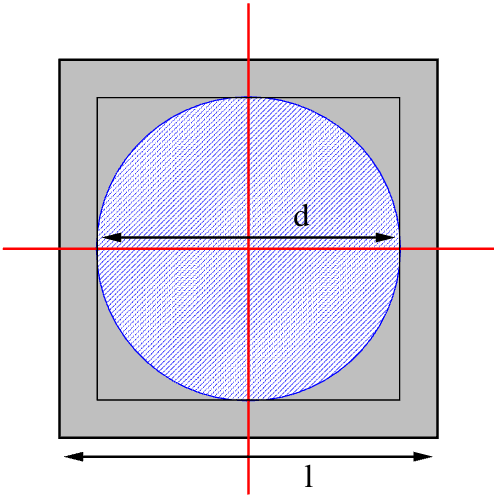

</div>

**Figure:** A ciricle of diameter $d$ surrounded by a square of length $l(l \geq d)$

## Question 1: 
Suggest a workflow to estimate $\pi$ from the fraction of points that fall in the first quarant $(x \in [0,l/2], y \in [0,l/2])$ of the circle. 
Complete the small Monte Carlo program to calculate $\pi$ using this method.


In [ ]:
numberOfPoints = 10000
l = 1.0
d = 1.0

x_coordinates = np.random.uniform(0, 1, numberOfPoints)
y_coordinates = np.random.uniform(0, 1, numberOfPoints)
x_scaled = l * x_coordinates / 2
y_scaled = l * y_coordinates / 2

# start refactor
distances = None
insideCircle = None
piEstimate = None
# end refactor

print(f"Score = {np.sum(insideCircle)} / {numberOfPoints} ({100 * np.mean(insideCircle):6.2f} %)")
print(r"π =", piEstimate)

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))

if insideCircle is not None:
    cmap = np.array(["red", "green"])
    ax.scatter(x_scaled, y_scaled, s=1, marker="x", c=cmap[insideCircle.astype(np.int32)])
else:
    ax.scatter(x_scaled, y_scaled, s=1, marker="x", c="red")


s = np.linspace(0, 0.5 * np.pi, 100)
ax.plot(0.5 * d * np.cos(s), 0.5 * d * np.sin(s), c="black", lw=3, ls="--")

<div style="max-width: 1000px; margin-left: 0; margin-right: auto; font-size: 20px; line-height: 1.6;">

How would you expect the accuracy of the result depends on the ratio $l/d$ and the number of generated coordinates?

<div style="max-width: 1000px; margin-left: 0; margin-right: auto; font-size: 20px; line-height: 1.6;">

## Question 2:
Derive a formula to calculate the relative standard deviation of the estimate of $\pi$. Hint: the distribution of successful hits is binomial. Is there an optimal ratio?

In [ ]:
def theoreticalStandardDeviation(n):
    # Compute the theoretical standard error of the mean of n points
    # start refactor
    return None
    # end refactor

In [ ]:
numberOfPoints = 100
numberOfRuns = 100
l = 1.0
d = 1.0

x_coordinates = np.random.uniform(0, 1, (numberOfRuns, numberOfPoints))
y_coordinates = np.random.uniform(0, 1, (numberOfRuns, numberOfPoints))
x_scaled = l * x_coordinates / 2
y_scaled = l * y_coordinates / 2

# start refactor
distances = None
insideCircle = None
piEstimates = None
# end refactor

print(f"Score = {np.sum(insideCircle)} / {numberOfPoints*numberOfRuns} ({100 * np.mean(insideCircle):6.2f} %)")
print(f"Theoretical standard deviation: {theoreticalStandardDeviation(numberOfPoints):8.6f}")
print(f"π = {np.mean(piEstimates):10.8f} ± {np.std(piEstimates):8.6f}")

<div style="max-width: 1000px; margin-left: 0; margin-right: auto; font-size: 20px; line-height: 1.6;">

## Question 3:
Is it a good idea to calculate many decimals of $\pi$ using this method?

In [ ]:
# Precompute means and standard deviations
max_points = 100000
n_runs = 1000  # Number of independent runs
l = 1
d = 1
x_all = np.random.uniform(0, 1, (n_runs, max_points))
y_all = np.random.uniform(0, 1, (n_runs, max_points))
x_all_box_l, y_all_box_l = x_all * l / 2, y_all * l / 2

# Precompute distances and inside_circle (array of bools) for all points
distances = np.sqrt(x_all_box_l**2 + y_all_box_l**2)
inside_circle = distances <= d / 2

# Precompute π estimates for all points and all runs
cumulative_inside_circle = np.cumsum(inside_circle, axis=1)

# start refactor
# end refactor

# Initialize plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Quarter Circle Visualization
ax1.set_title("Quarter Circle (First Quadrant)")
ax1.set_xlim(0, l / 2)
ax1.set_ylim(0, l / 2)
circle = Circle((0, 0), d / 2, color="blue", fill=False)
ax1.add_artist(circle)
scat = ax1.scatter([], [], s=1)

# Pi Estimation Plot
ax2.set_title("Estimation of Pi")
ax2.set_xlim(1, max_points)
ax2.set_ylim(2.5, 4)
ax2.set_xscale("log")
(line_mean,) = ax2.plot([], [], color="b", label="Mean Pi Estimate")
true_pi_line = ax2.axhline(y=np.pi, color="r", linestyle="-", label="True Pi")
n = np.arange(1, max_points, 1)
if theoreticalStandardDeviation(n) is not None:
    true_std = ax2.plot(n, np.pi + theoreticalStandardDeviation(n), label="theoretical_StdErr")
fill_std = ax2.fill_between([], [], [], color="gray", alpha=0.3)
ax2.legend()


# Update function for animation
def update(frame):
    num_points = frame + 1

    # Update scatter plot
    x = x_all_box_l[0, :num_points]
    y = y_all_box_l[0, :num_points]
    colors = np.where(inside_circle[0, :num_points], "green", "red")
    scat.set_offsets(np.c_[x, y])
    scat.set_color(colors)

    # Update mean Pi estimate plot
    line_mean.set_data(range(1, num_points + 1), means[:num_points])

    # Update standard deviation fill
    global fill_std
    fill_std.remove()
    fill_std = ax2.fill_between(
        range(1, num_points + 1),
        means[:num_points] - std_devs[:num_points],
        means[:num_points] + std_devs[:num_points],
        color="gray",
        alpha=0.3,
    )


n_frames = 20  # Number of frames to show in the animation


# Generate a nonlinear frame progression
def nonlinear_frame_progression(n_frames, max_points):
    base = np.geomspace(1, max_points - 1, n_frames // 2, dtype=int)  # Logarithmic-like steps
    fine = np.unique(np.linspace(1, max_points - 1, n_frames // 2, dtype=int))  # Linear steps
    return np.unique(np.sort(np.concatenate((base, fine))))


# Generate the frame indices
frame_indices = nonlinear_frame_progression(n_frames, max_points)
# Animation
ani = FuncAnimation(fig, update, frames=frame_indices, interval=50, repeat=False)

# Display the animation inline in Jupyter Notebook
from IPython.display import HTML

plt.close(fig)
HTML(ani.to_jshtml())

In [ ]:
# Plot the standard deviation of the mean of n points
points = np.arange(1, max_points)
plt.plot(std_devs, ".", label="measured std")
plt.plot(points, theoreticalStandardDeviation(points), label=r"$\propto n^{-1/2}$")
plt.yscale("log")
plt.xscale("log")
plt.xlabel("Number of samples")
plt.ylabel("Standard deviation")
plt.legend()

<div style="max-width: 1000px; margin-left: 0; margin-right: auto; font-size: 20px; line-height: 1.6;">

### Question 4:
How would the computation of $\pi$ change when going to 3d or 4d.

In [ ]:
def estimate_pi_monte_carlo(n_dim: int, num_samples: int) -> float:
    # Generate random points in the n-dimensional unit cube
    points = np.random.uniform(0, 1, (num_samples, n_dim))
    distances = np.sqrt(np.sum(points**2, axis=1))

    # start refactor
    inside_sphere = None
    # end refactor
    fraction = np.sum(inside_sphere) / num_samples

    # Calculate pi based on dimensionality
    if n_dim == 2:
        # start refactor
        estimated_pi = None
        # end refactor
    elif n_dim == 3:
        # start refactor
        estimated_pi = None
        # end refactor
    elif n_dim == 4:
        # start refactor
        estimated_pi = None
        # end refactor
    else:
        raise ValueError("We look at 2D,3D and 4D only.")

    return estimated_pi


# Estimate pi in 2D, 3D and 4D
num_samples = 100000

pi_2d = estimate_pi_monte_carlo(2, num_samples)
print(f"Estimated pi in 3D: {pi_2d}")

pi_3d = estimate_pi_monte_carlo(3, num_samples)
print(f"Estimated pi in 3D: {pi_3d}")

pi_4d = estimate_pi_monte_carlo(4, num_samples)
print(f"Estimated pi in 4D: {pi_4d}")

<div style="max-width: 1000px; margin-left: 0; margin-right: auto; font-size: 20px; line-height: 1.6;">

### Possible additional questions: Question 5:
Why are Monte Carlo methods particularly effective in higher dimensions compared to traditional numerical integration techniques?

Explain how the complexity of traditional integration methods scales with the number of dimensions (e.g., 2D, 3D, 4D).

Highlight the need for exponentially more grid points in traditional methods as dimensions increase.
Discuss the “curse of dimensionality” and its impact on grid-based approaches.
How does the Monte Carlo method avoid this issue?

Explain how Monte Carlo sampling operates independently of dimensionality.
Discuss the convergence rate of Monte Carlo methods which scales as $\mathcal{O}(1/\sqrt{n})$
 and why it remains effective even in higher dimensions.
